# 020 — Time To Profit Or Loss

Цель: оценить, через сколько времени после текущего состояния рынка достигаются движения `mid_px` вверх/вниз на заданные пороги в тиках.


## 1) Setup и конфиг

Ноутбук использует векторизованный chunk-based подход:
- для каждого чанка считаем матрицу будущих `delta_ticks` до 60s
- извлекаем first-hit time для `+threshold` и `-threshold`
- без Python-циклов по каждой строке датасета


In [23]:
from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Root detection
_cwd = Path.cwd().resolve()
_cands = [_cwd, _cwd.parent, _cwd.parent.parent, _cwd.parent.parent.parent]
ROOT = None
for c in _cands:
    if (c / "research").exists() and (c / "notebooks").exists():
        ROOT = c
        break
if ROOT is None:
    raise RuntimeError("Could not detect repo root")
print("ROOT:", ROOT)

# Config
TICK_SIZE = 0.1
THRESHOLDS_TICKS = [100, 200, 300, 400, 500, 600]
HORIZONS_SEC = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 30, 60, 90, 120, 150, 180]
MAX_HORIZON_SEC = 180.0
CHUNK_SIZE = 20_000

# Path to reconstructed dataframe parquet
PARQUET_PATH = ROOT / "data" / "processed" / "modeling" / "btc_usdt_swap_model_dataset_100ms_baseline_20260323_000000__20260325_235959.parquet"
print("PARQUET_PATH exists:", PARQUET_PATH.exists())


ROOT: D:\tumar\okx-hft-research
PARQUET_PATH exists: True


## 2) Загрузка данных

Берем только нужные колонки и сортируем по времени.


In [24]:
import pyarrow.parquet as pq

requested_cols = ["ts_event", "mid_px", "spread_px"]
requested_cols += [f"bid_px_{i:02d}" for i in range(1, 11)]
requested_cols += [f"bid_sz_{i:02d}" for i in range(1, 11)]
requested_cols += [f"ask_px_{i:02d}" for i in range(1, 11)]
requested_cols += [f"ask_sz_{i:02d}" for i in range(1, 11)]

available_cols = pq.read_schema(PARQUET_PATH).names
cols_to_read = [c for c in requested_cols if c in available_cols]
missing_cols = [c for c in requested_cols if c not in available_cols]

required_min = ["ts_event", "mid_px", "spread_px"]
missing_required_min = [c for c in required_min if c not in cols_to_read]
if missing_required_min:
    raise ValueError(
        "Parquet does not contain minimal required columns: "
        + ", ".join(missing_required_min)
    )

if missing_cols:
    print(f"[info] Missing optional top-book columns: {len(missing_cols)}")
    print("[info] First missing columns:", missing_cols[:10])

df = pd.read_parquet(PARQUET_PATH, columns=cols_to_read)
df["ts_event"] = pd.to_datetime(df["ts_event"], utc=True, errors="coerce")
df = df.dropna(subset=["ts_event", "mid_px"]).sort_values("ts_event").reset_index(drop=True)
print("rows:", len(df), "cols:", len(df.columns))
display(df.head(3))


[info] Missing optional top-book columns: 40
[info] First missing columns: ['bid_px_01', 'bid_px_02', 'bid_px_03', 'bid_px_04', 'bid_px_05', 'bid_px_06', 'bid_px_07', 'bid_px_08', 'bid_px_09', 'bid_px_10']
rows: 2592052 cols: 3


,ts_event,mid_px,spread_px
0,2026-03-23 00:00:00+00:00,67830.85,0.1
1,2026-03-23 00:00:00.100000+00:00,67830.85,0.1
2,2026-03-23 00:00:00.200000+00:00,67830.85,0.1


## 3) Вспомогательные функции


In [25]:
def estimate_grid_dt_seconds(ts: pd.Series) -> float:
    d = ts.diff().dt.total_seconds().dropna()
    if d.empty:
        raise ValueError("Not enough timestamps to estimate dt")
    return float(d.median())


def compute_first_hit_times_chunked(
    mid_px: np.ndarray,
    tick_size: float,
    thresholds_ticks: list[int],
    dt_sec: float,
    max_horizon_sec: float,
    chunk_size: int,
) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    n = mid_px.shape[0]
    max_steps = int(round(max_horizon_sec / dt_sec))
    if max_steps <= 0:
        raise ValueError("max_steps <= 0")

    plus = {th: np.full(n, np.nan, dtype=np.float32) for th in thresholds_ticks}
    minus = {th: np.full(n, np.nan, dtype=np.float32) for th in thresholds_ticks}

    valid_n = n - max_steps
    if valid_n <= 0:
        raise ValueError("Dataset shorter than max_horizon window")

    offsets = np.arange(1, max_steps + 1, dtype=np.int32)

    for start in range(0, valid_n, chunk_size):
        end = min(start + chunk_size, valid_n)
        base_idx = np.arange(start, end, dtype=np.int64)
        fut_idx = base_idx[:, None] + offsets[None, :]

        cur_mid = mid_px[base_idx][:, None]
        fut_mid = mid_px[fut_idx]
        delta_ticks = (fut_mid - cur_mid) / tick_size

        for th in thresholds_ticks:
            m_plus = delta_ticks >= th
            has_plus = m_plus.any(axis=1)
            first_plus = m_plus.argmax(axis=1) + 1
            t_plus = np.where(has_plus, first_plus * dt_sec, np.nan).astype(np.float32)
            plus[th][start:end] = t_plus

            m_minus = delta_ticks <= -th
            has_minus = m_minus.any(axis=1)
            first_minus = m_minus.argmax(axis=1) + 1
            t_minus = np.where(has_minus, first_minus * dt_sec, np.nan).astype(np.float32)
            minus[th][start:end] = t_minus

    return plus, minus


def summarize_thresholds(plus: dict[int, np.ndarray], minus: dict[int, np.ndarray]) -> pd.DataFrame:
    rows = []
    for th in sorted(plus):
        p = plus[th]
        m = minus[th]
        rows.append(
            {
                "threshold_ticks": th,
                "share_reached_plus": float(np.mean(~np.isnan(p))),
                "share_reached_minus": float(np.mean(~np.isnan(m))),
                "median_time_plus_sec": float(np.nanmedian(p)) if np.any(~np.isnan(p)) else np.nan,
                "p75_time_plus_sec": float(np.nanpercentile(p, 75)) if np.any(~np.isnan(p)) else np.nan,
                "p90_time_plus_sec": float(np.nanpercentile(p, 90)) if np.any(~np.isnan(p)) else np.nan,
                "median_time_minus_sec": float(np.nanmedian(m)) if np.any(~np.isnan(m)) else np.nan,
                "p75_time_minus_sec": float(np.nanpercentile(m, 75)) if np.any(~np.isnan(m)) else np.nan,
                "p90_time_minus_sec": float(np.nanpercentile(m, 90)) if np.any(~np.isnan(m)) else np.nan,
            }
        )
    return pd.DataFrame(rows).sort_values("threshold_ticks").reset_index(drop=True)


## 4) Расчет first-hit times до ±threshold


In [26]:
dt_sec = estimate_grid_dt_seconds(df["ts_event"])
print("estimated dt_sec:", dt_sec)

mid = df["mid_px"].to_numpy(dtype=np.float64)
plus_times, minus_times = compute_first_hit_times_chunked(
    mid_px=mid,
    tick_size=TICK_SIZE,
    thresholds_ticks=THRESHOLDS_TICKS,
    dt_sec=dt_sec,
    max_horizon_sec=MAX_HORIZON_SEC,
    chunk_size=CHUNK_SIZE,
)

for th in THRESHOLDS_TICKS:
    df[f"seconds_to_plus_{th}_ticks"] = plus_times[th]
    df[f"seconds_to_minus_{th}_ticks"] = minus_times[th]

display(df[["ts_event", "mid_px", "seconds_to_plus_100_ticks", "seconds_to_minus_100_ticks"]].head())


estimated dt_sec: 0.1


,ts_event,mid_px,seconds_to_plus_100_ticks,seconds_to_minus_100_ticks
0,2026-03-23 00:00:00+00:00,67830.85,0.4,NaN
1,2026-03-23 00:00:00.100000+00:00,67830.85,0.3,NaN
2,2026-03-23 00:00:00.200000+00:00,67830.85,0.2,NaN
3,2026-03-23 00:00:00.300000+00:00,67840.65,3.2,NaN
4,2026-03-23 00:00:00.400000+00:00,67843.85,4.4,NaN


## 5) Summary table по thresholds


In [27]:
summary_df = summarize_thresholds(plus_times, minus_times)
display(summary_df.style.format({c: "{:.4f}" for c in summary_df.columns if c != "threshold_ticks"}))


,threshold_ticks,share_reached_plus,share_reached_minus,median_time_plus_sec,p75_time_plus_sec,p90_time_plus_sec,median_time_minus_sec,p75_time_minus_sec,p90_time_minus_sec
0,100,0.8135,0.8069,14.1000,40.3000,86.8000,13.5000,39.0000,86.7000
1,200,0.7018,0.6910,28.2000,65.6000,114.7000,27.1000,64.8000,115.8000
2,300,0.6023,0.5888,42.7000,86.3000,131.3000,40.8000,84.1000,131.3000
3,400,0.5139,0.4948,54.9000,100.7000,141.8000,52.4000,98.2000,141.0000
4,500,0.4332,0.4126,66.3000,111.1000,147.5000,62.3000,108.2000,146.7000
5,600,0.3617,0.3438,73.9000,118.8000,152.3000,71.4000,116.1000,151.4000


## 6) Heatmaps: доля достижения threshold к horizon


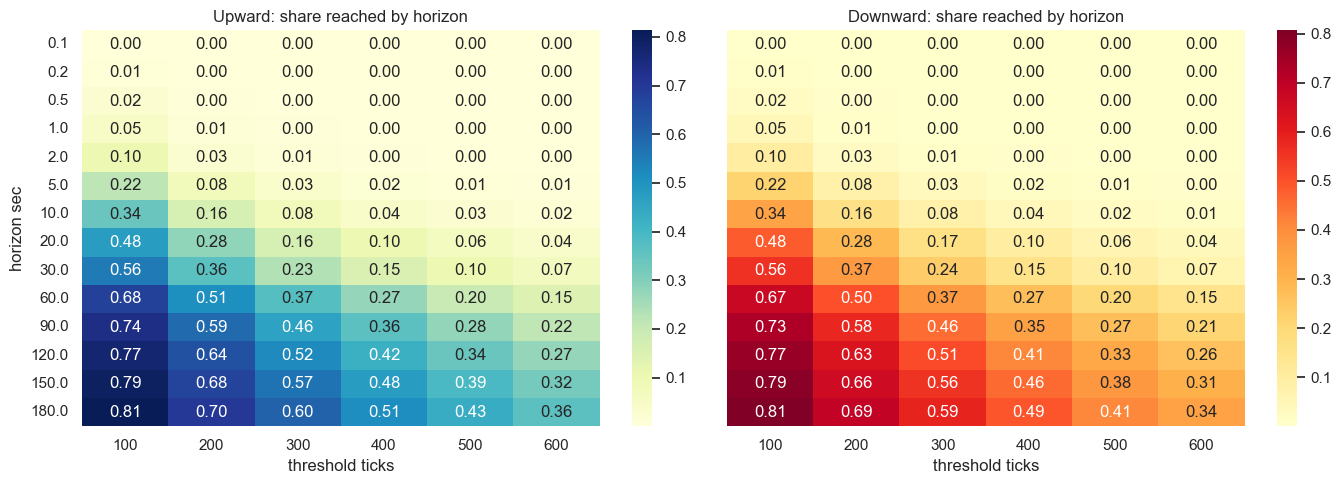

In [28]:
def build_reached_heatmap(times_dict: dict[int, np.ndarray], thresholds: list[int], horizons_sec: list[float]) -> pd.DataFrame:
    mat = []
    for h in horizons_sec:
        row = []
        for th in thresholds:
            t = times_dict[th]
            row.append(float(np.mean((~np.isnan(t)) & (t <= h))))
        mat.append(row)
    return pd.DataFrame(mat, index=horizons_sec, columns=thresholds)

heat_up = build_reached_heatmap(plus_times, THRESHOLDS_TICKS, HORIZONS_SEC)
heat_dn = build_reached_heatmap(minus_times, THRESHOLDS_TICKS, HORIZONS_SEC)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.heatmap(heat_up, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Upward: share reached by horizon")
axes[0].set_xlabel("threshold ticks")
axes[0].set_ylabel("horizon sec")

sns.heatmap(heat_dn, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Downward: share reached by horizon")
axes[1].set_xlabel("threshold ticks")
plt.tight_layout()
plt.show()


## 7) Survival-style curves: P(move reached by t)


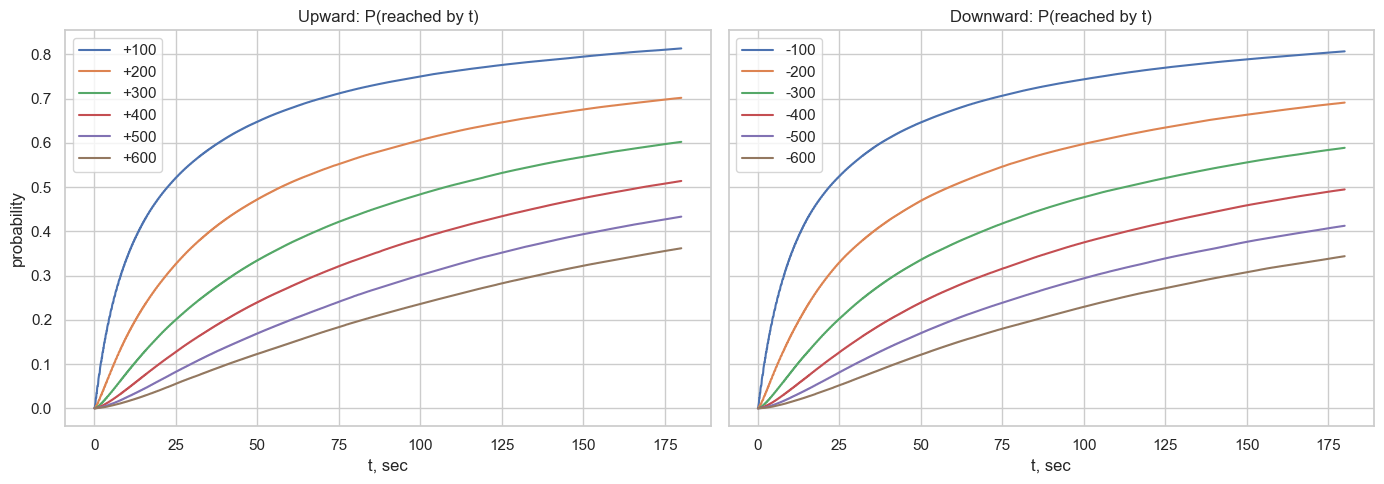

In [29]:
t_grid = np.arange(dt_sec, MAX_HORIZON_SEC + dt_sec, dt_sec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for th in THRESHOLDS_TICKS:
    p = plus_times[th]
    y = np.array([np.mean((~np.isnan(p)) & (p <= t)) for t in t_grid])
    axes[0].plot(t_grid, y, label=f"+{th}")
axes[0].set_title("Upward: P(reached by t)")
axes[0].set_xlabel("t, sec")
axes[0].set_ylabel("probability")
axes[0].legend()

for th in THRESHOLDS_TICKS:
    m = minus_times[th]
    y = np.array([np.mean((~np.isnan(m)) & (m <= t)) for t in t_grid])
    axes[1].plot(t_grid, y, label=f"-{th}")
axes[1].set_title("Downward: P(reached by t)")
axes[1].set_xlabel("t, sec")
axes[1].legend()
plt.tight_layout()
plt.show()


## 8) Probability table for selected horizons


In [30]:
sel_h = [1, 5, 10, 30, 60]

def prob_table(times_dict: dict[int, np.ndarray], thresholds: list[int], horizons: list[int], side: str) -> pd.DataFrame:
    rows = []
    for th in thresholds:
        t = times_dict[th]
        row = {"threshold_ticks": th}
        for h in horizons:
            row[f"prob_reached_in_{h}s"] = float(np.mean((~np.isnan(t)) & (t <= h)))
        rows.append(row)
    out = pd.DataFrame(rows)
    out.insert(1, "direction", side)
    return out

prob_up_df = prob_table(plus_times, THRESHOLDS_TICKS, sel_h, "up")
prob_dn_df = prob_table(minus_times, THRESHOLDS_TICKS, sel_h, "down")

display(prob_up_df)
display(prob_dn_df)


,threshold_ticks,direction,prob_reached_in_1s,prob_reached_in_5s,prob_reached_in_10s,prob_reached_in_30s,prob_reached_in_60s
0,100,up,0.050366,0.217143,0.340340,0.555744,0.677683
1,200,up,0.011088,0.082178,0.163706,0.364666,0.509579
2,300,up,0.003469,0.034606,0.080853,0.232306,0.373181
3,400,up,0.001471,0.016841,0.043491,0.153065,0.274464
4,500,up,0.000775,0.009143,0.025005,0.101362,0.199094
5,600,up,0.000473,0.005473,0.015357,0.069661,0.147344


,threshold_ticks,direction,prob_reached_in_1s,prob_reached_in_5s,prob_reached_in_10s,prob_reached_in_30s,prob_reached_in_60s
0,100,down,0.050118,0.216364,0.343526,0.558034,0.674262
1,200,down,0.010408,0.081142,0.162022,0.365924,0.503867
2,300,down,0.003035,0.033479,0.079794,0.235097,0.371738
3,400,down,0.001182,0.015492,0.041981,0.152124,0.272981
4,500,down,0.000600,0.007950,0.023668,0.100538,0.199860
5,600,down,0.000326,0.004447,0.014038,0.065954,0.146279


## 9) Volatility regimes (low / medium / high)


In [31]:
returns_ticks = (df["mid_px"].diff() / TICK_SIZE).astype(float)
win_10s = max(int(round(10.0 / dt_sec)), 2)
df["realized_vol_10s_ticks"] = returns_ticks.rolling(win_10s, min_periods=max(2, win_10s // 4)).std()

vol_q = df["realized_vol_10s_ticks"].quantile([1/3, 2/3]).to_numpy()
q1, q2 = vol_q[0], vol_q[1]
df["vol_regime"] = pd.cut(
    df["realized_vol_10s_ticks"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["low", "medium", "high"],
)

print("regime counts:")
display(df["vol_regime"].value_counts(dropna=False))

regime_summary_rows = []
for regime in ["low", "medium", "high"]:
    idx = (df["vol_regime"] == regime).to_numpy()
    if idx.sum() == 0:
        continue
    for th in THRESHOLDS_TICKS:
        p = plus_times[th][idx]
        m = minus_times[th][idx]
        regime_summary_rows.append(
            {
                "vol_regime": regime,
                "threshold_ticks": th,
                "share_reached_plus": float(np.mean(~np.isnan(p))),
                "share_reached_minus": float(np.mean(~np.isnan(m))),
                "median_time_plus_sec": float(np.nanmedian(p)) if np.any(~np.isnan(p)) else np.nan,
                "median_time_minus_sec": float(np.nanmedian(m)) if np.any(~np.isnan(m)) else np.nan,
            }
        )

regime_summary_df = pd.DataFrame(regime_summary_rows)
display(regime_summary_df.head(18))


regime counts:


vol_regime
low       864026
high      864006
medium    863995
NaN           25
Name: count, dtype: int64

,vol_regime,threshold_ticks,share_reached_plus,share_reached_minus,median_time_plus_sec,median_time_minus_sec
0,low,100,0.777877,0.757819,21.799999,21.200001
1,low,200,0.647067,0.618228,39.099998,39.000000
2,low,300,0.534874,0.501469,58.099998,57.000000
3,low,400,0.436735,0.392913,71.800003,71.800003
4,low,500,0.349017,0.306083,84.400002,84.000000
5,low,600,0.274298,0.238133,92.099998,94.300003
6,medium,100,0.804351,0.801237,15.500000,14.800000
7,medium,200,0.687549,0.681816,31.100000,30.700001
8,medium,300,0.585333,0.572392,46.799999,45.900002
9,medium,400,0.495203,0.475873,61.099998,58.700001


## 10) Conclusions (auto)


In [32]:
def _safe_med(series: pd.Series) -> float:
    s = series.dropna()
    return float(s.median()) if len(s) else np.nan

s100 = summary_df.loc[summary_df["threshold_ticks"] == 100]
s300 = summary_df.loc[summary_df["threshold_ticks"] == 300]
s600 = summary_df.loc[summary_df["threshold_ticks"] == 600]

med_100_plus = float(s100["median_time_plus_sec"].iloc[0]) if len(s100) else np.nan
p5_300_plus = float(prob_up_df.loc[prob_up_df["threshold_ticks"] == 300, "prob_reached_in_5s"].iloc[0]) if len(s300) else np.nan
p60_600_plus = float(prob_up_df.loc[prob_up_df["threshold_ticks"] == 600, "prob_reached_in_60s"].iloc[0]) if len(s600) else np.nan

high_600 = regime_summary_df[(regime_summary_df["vol_regime"] == "high") & (regime_summary_df["threshold_ticks"] == 600)]
low_600 = regime_summary_df[(regime_summary_df["vol_regime"] == "low") & (regime_summary_df["threshold_ticks"] == 600)]
high_share_600 = float(high_600["share_reached_plus"].iloc[0]) if len(high_600) else np.nan
low_share_600 = float(low_600["share_reached_plus"].iloc[0]) if len(low_600) else np.nan

realistic_row = prob_up_df.copy()
realistic_row["score"] = realistic_row["prob_reached_in_10s"]
best = realistic_row.sort_values("score", ascending=False).iloc[0]

conclusions = [
    f"- 100 ticks вверх обычно достигаются за ~{med_100_plus:.2f} сек (median)." if pd.notna(med_100_plus) else "- Для 100 ticks не удалось оценить median (недостаточно достижений).",
    f"- Для 300 ticks вероятность достижения за 5 сек: ~{p5_300_plus:.3f}." if pd.notna(p5_300_plus) else "- Для 300 ticks недостаточно данных для оценки за 5 сек.",
    f"- Для 600 ticks вероятность достижения за 60 сек: ~{p60_600_plus:.3f}." if pd.notna(p60_600_plus) else "- Для 600 ticks недостаточно данных для оценки за 60 сек.",
    f"- 600 ticks заметно чаще в high-vol режиме ({high_share_600:.3f}) vs low-vol ({low_share_600:.3f})." if pd.notna(high_share_600) and pd.notna(low_share_600) else "- Не удалось полноценно сравнить 600 ticks по vol-regimes.",
    f"- Наиболее реалистичный trading horizon по критерию prob_reached_in_10s: threshold={int(best['threshold_ticks'])} ticks (p≈{best['score']:.3f}).",
]

print("Conclusions")
print("\n".join(conclusions))


Conclusions
- 100 ticks вверх обычно достигаются за ~14.10 сек (median).
- Для 300 ticks вероятность достижения за 5 сек: ~0.035.
- Для 600 ticks вероятность достижения за 60 сек: ~0.147.
- 600 ticks заметно чаще в high-vol режиме (0.475) vs low-vol (0.274).
- Наиболее реалистичный trading horizon по критерию prob_reached_in_10s: threshold=100 ticks (p≈0.340).
